### When Does This Business Actually Make Its Money?

A retail superstore has years of sales data, but when are sales actually the highest? Are sales growing over time, or staying flat? And is the drop in some months actually a problem, or just a normal yearly pattern?

In this project, I’ll use Python and Pandas to explore the data and turn it into useful business insights.

Dataset: Superstore Sales (Kaggle)

Tools: Python, Pandas, Matplotlib, Seaborn

### Step 1 Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 25)

### Step 2 Loading the Data

In [2]:
df = pd.read_csv(r"E:\superstore-trend-analysis\data\raw\Sample - Superstore.csv", encoding="latin-1")
df["Order Date"] = pd.to_datetime(df["Order Date"])
print(f"Rows: {df.shape[0]}, Date range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
df.head()

Rows: 9994, Date range: 2014-01-03 to 2017-12-30


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


### Step 3 : Preparing Data Columns

In [3]:
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10


### Step 4 Monthly Sales Trend

In [4]:
monthly_sales = df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum()
monthly_sales.head()

Order Date
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

### Step 5 : Seasonality

In [5]:
seasonal_sales = df.groupby("Month")["Sales"].sum().sort_values(ascending=False)
seasonal_sales

Month
11    352461.0710
12    325293.5035
9     307649.9457
3     205005.4888
10    200322.9847
8     159044.0630
5     155028.8117
6     152718.6793
7     147238.0970
4     137762.1286
1      94924.8356
2      59751.2514
Name: Sales, dtype: float64

#### Step 6 : Year over Year Growth

In [6]:
yearly_sales = df.groupby("Year")["Sales"].sum()
yearly_growth = (yearly_sales.pct_change() * 100).round(1)
pd.DataFrame({"Sales": yearly_sales, "Growth_percent": yearly_growth})

,Sales,Growth_percent
Year,,
2014,484247.4981,NaN
2015,470532.5090,-2.8
2016,609205.5980,29.5
2017,733215.2552,20.4


## Step 7: The Mystery Question

In [7]:
jan_by_year = df[df["Month"]==1].groupby("Year")["Sales"].sum()
feb_by_year = df[df["Month"]==2].groupby("Year")["Sales"].sum()
dec_by_year = df[df["Month"]==12].groupby("Year")["Sales"].sum()

pd.DataFrame({"December": dec_by_year, "January_next": jan_by_year.reindex(dec_by_year.index), "February": feb_by_year})

,December,January_next,February
Year,,,
2014,69545.6205,14236.8950,4519.8920
2015,74919.5212,18174.0756,11951.4110
2016,96999.0430,18542.4910,22978.8150
2017,83829.3188,43971.3740,20301.1334


### Step 8:  Visualization1 , Monthly sales Trend

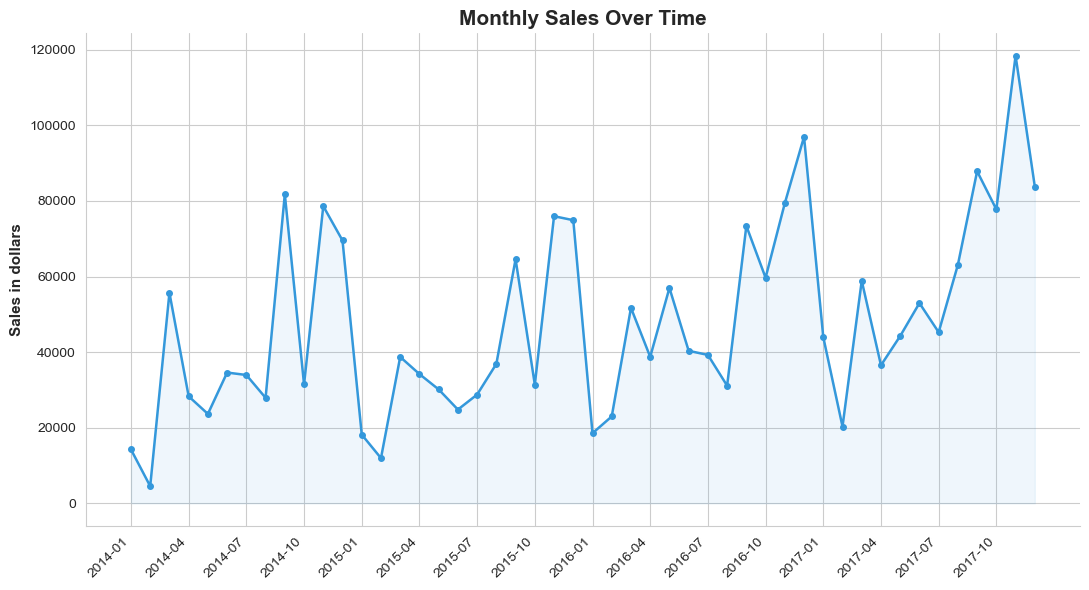

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(monthly_sales.index.astype(str), monthly_sales.values, marker="o", markersize=4,
        color="#3498db", linewidth=1.8)
ax.fill_between(range(len(monthly_sales)), monthly_sales.values, alpha=0.08, color="#3498db")

ax.set_xticks(range(0, len(monthly_sales), 3))
ax.set_xticklabels([monthly_sales.index.astype(str)[i] for i in range(0, len(monthly_sales), 3)], rotation=45, ha="right")

ax.set_title("Monthly Sales Over Time", fontsize=15, fontweight="bold")
ax.set_ylabel("Sales in dollars", fontsize=11, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Visualization 1
Sales rise and fall in a repeating pattern every year, with a clear overall upward trend from 2014 to 2017.

### Step 9: Visualization 2, Seasonality by Calendar Month

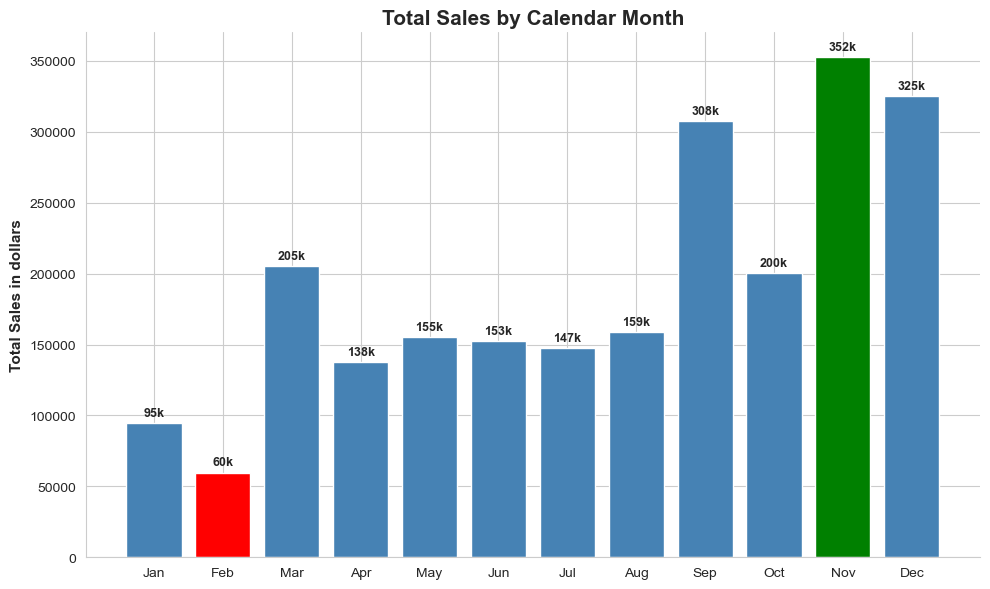

In [9]:
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
seasonal = df.groupby("Month")["Sales"].sum()
colors = ["red" if v == seasonal.min() else ("green" if v == seasonal.max() else "steelblue") for v in seasonal.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(month_names, seasonal.values, color=colors, edgecolor="white")

for bar, val in zip(bars, seasonal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000, f"{val/1000:.0f}k",
            ha="center", fontsize=9, fontweight="bold")

ax.set_title("Total Sales by Calendar Month", fontsize=15, fontweight="bold")
ax.set_ylabel("Total Sales in dollars", fontsize=11, fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.show()

### Visualization 2
November is the strongest month across all years, while February is consistently the weakest.

### Step 10: Business Recommendations
1. Stock up and focus more on marketing from September to December, as this is usually the time when sales are highest.

2. Don’t worry too much about the drop in January and February. It happens every year and is a normal seasonal pattern, not a business problem.

3. Check what changed in 2016. Sales growth increased a lot compared to the previous year, so understanding what caused it could help us repeat that success.



### Conclusion

Sales usually increase toward the end of the year and drop in January and February. Overall, the business is growing. Understanding this seasonal pattern helps plan inventory, staffing, and marketing better.
